## 1.Importing Libs and Dataset

In [1]:
from statsbombpy import sb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from mplsoccer import Pitch
import pandas as pd
import ast 
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

In [2]:
shots = pd.read_csv(r'C:\Users\ahmed\Desktop\Fanalysis\1\shots_2015_16.csv')

## 2.Preprocessing

In [3]:
print(shots[['location', 'shot_body_part', 'shot_technique', 
             'shot_type', 'shot_outcome', 'shot_statsbomb_xg',
             'shot_first_time', 'shot_one_on_one', 
             'under_pressure', 'shot_aerial_won']].head())

        location shot_body_part shot_technique  shot_type shot_outcome  \
0   [94.5, 42.9]      Left Foot         Normal  Open Play      Blocked   
1   [93.5, 48.4]     Right Foot         Normal  Open Play        Saved   
2   [89.8, 22.3]     Right Foot         Normal  Open Play        Off T   
3   [98.2, 26.0]     Right Foot         Normal  Open Play        Saved   
4  [105.7, 24.2]     Right Foot         Normal  Open Play        Saved   

   shot_statsbomb_xg shot_first_time shot_one_on_one under_pressure  \
0           0.038832            True             NaN            NaN   
1           0.031541             NaN             NaN           True   
2           0.006660             NaN             NaN           True   
3           0.022902             NaN             NaN            NaN   
4           0.049741             NaN             NaN            NaN   

  shot_aerial_won  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  


In [4]:
shots['location'] = shots['location'].apply(ast.literal_eval)

shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])

shots['goal'] = (shots['shot_outcome'] == 'Goal').astype(int)

print(shots['goal'].value_counts())
print(f"\nGoal rate: {shots['goal'].mean():.3f}")
print(shots[['x', 'y']].head())

print(type(shots['location'].iloc[0]))
print(shots['location'].iloc[0])

goal
0    8920
1     988
Name: count, dtype: int64

Goal rate: 0.100
       x     y
0   94.5  42.9
1   93.5  48.4
2   89.8  22.3
3   98.2  26.0
4  105.7  24.2
<class 'list'>
[94.5, 42.9]


In [5]:
shots['distance'] = np.sqrt(
    ((120 - shots['x']) ** 2) + ((40 - shots['y']) ** 2)
    )
print(shots['distance'].head())

dx = 120 - shots['x']
dy_left = 36 - shots['y']
dy_right = 44 - shots['y']

shots['angle'] = abs(np.arctan2(dy_left, dx) - np.arctan2(dy_right, dx))

print(shots['angle'].head())

0    25.664372
1    27.799460
2    35.004714
3    25.908300
4    21.310326
Name: distance, dtype: float64
0    0.307371
1    0.273123
2    0.197184
3    0.260131
4    0.255407
Name: angle, dtype: float64


In [6]:
shots['shot_first_time'] = shots['shot_first_time'].fillna(False)
shots['shot_one_on_one'] = shots['shot_one_on_one'].fillna(False)
shots['under_pressure'] = shots['under_pressure'].fillna(False)
shots['shot_aerial_won'] = shots['shot_aerial_won'].fillna(False)


C:\Users\ahmed\AppData\Local\Temp\ipykernel_24148\53885071.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shots['shot_first_time'] = shots['shot_first_time'].fillna(False)
C:\Users\ahmed\AppData\Local\Temp\ipykernel_24148\53885071.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shots['shot_one_on_one'] = shots['shot_one_on_one'].fillna(False)
C:\Users\ahmed\AppData\Local\Temp\ipykernel_24148\53885071.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infe

In [7]:
cat_columns = ['shot_body_part', 'shot_technique', 'shot_type']
shots = pd.get_dummies(shots, columns=cat_columns, drop_first=True)

# Verify
print(shots.columns.tolist())

['bad_behaviour_card', 'ball_receipt_outcome', 'ball_recovery_recovery_failure', 'block_deflection', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_other', 'clearance_right_foot', 'counterpress', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'injury_stoppage_in_chain', 'interception_outcome', 'location', 'match_id', 'minute', 'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_deflected', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_outcome', 'pass_outswingin

In [8]:
feature_cols = [
    'distance', 'angle',
    'shot_first_time', 'shot_one_on_one', 
    'under_pressure', 'shot_aerial_won',
    'shot_body_part_Left Foot', 'shot_body_part_Right Foot', 'shot_body_part_Other',
    'shot_technique_Diving Header', 'shot_technique_Half Volley',
    'shot_technique_Lob', 'shot_technique_Normal',
    'shot_technique_Overhead Kick', 'shot_technique_Volley',
    'shot_type_Free Kick', 'shot_type_Open Play', 'shot_type_Penalty'
]

X = shots[feature_cols]
y = shots['goal']

print(X.shape)
print(y.value_counts())

(9908, 18)
goal
0    8920
1     988
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

## 3.Models

### 1.LogisticRegression

In [10]:
params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [500]
}

logreg = LogisticRegression()
kf = KFold(n_splits= 5, random_state= 42, shuffle= True)

log_grid = GridSearchCV(
    logreg,
    param_grid= params, 
    cv= kf,
    scoring='neg_log_loss'
    )

log_grid.fit(X_train, y_train)
y_pred = log_grid.predict_proba(X_test)[:, 1]

best_param_knn = log_grid.best_params_
print(log_grid.best_params_)
print(log_grid.best_score_)
print(y_pred)

{'C': 1, 'max_iter': 500, 'solver': 'liblinear'}
-0.26806585514333525
[0.01923614 0.05770489 0.02960008 ... 0.02252066 0.03125956 0.03074264]


### 2.Gradient Boosting

In [11]:
params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}

xgb_model= xgb.XGBClassifier()
xgb_grid= GridSearchCV(xgb_model, param_grid= params, cv= kf, scoring= 'neg_log_loss')
xgb_grid.fit(X_train, y_train)
y_pred = xgb_grid.predict_proba(X_test)[:, 1]
print(xgb_grid.best_params_)
print(xgb_grid.best_score_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
-0.2657848883267143


## 4.Visualizations

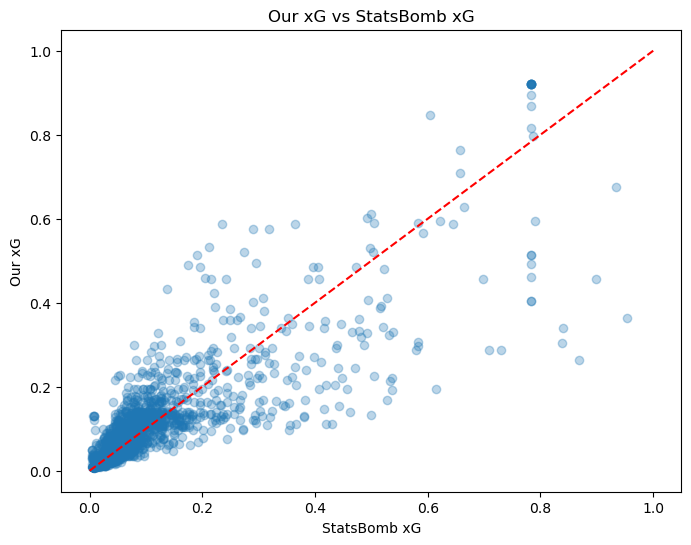

Correlation: 0.841


In [12]:
X_test_copy = X_test.copy()
X_test_copy['our_xg'] = y_pred
X_test_copy['statsbomb_xg'] = shots.loc[X_test.index, 'shot_statsbomb_xg']

plt.figure(figsize=(8, 6))
plt.scatter(X_test_copy['statsbomb_xg'], X_test_copy['our_xg'], alpha=0.3)
plt.plot([0, 1], [0, 1], 'r--')  # perfect agreement line
plt.xlabel('StatsBomb xG')
plt.ylabel('Our xG')
plt.title('Our xG vs StatsBomb xG')
plt.show()

# Correlation
print(f"Correlation: {X_test_copy['our_xg'].corr(X_test_copy['statsbomb_xg']):.3f}")

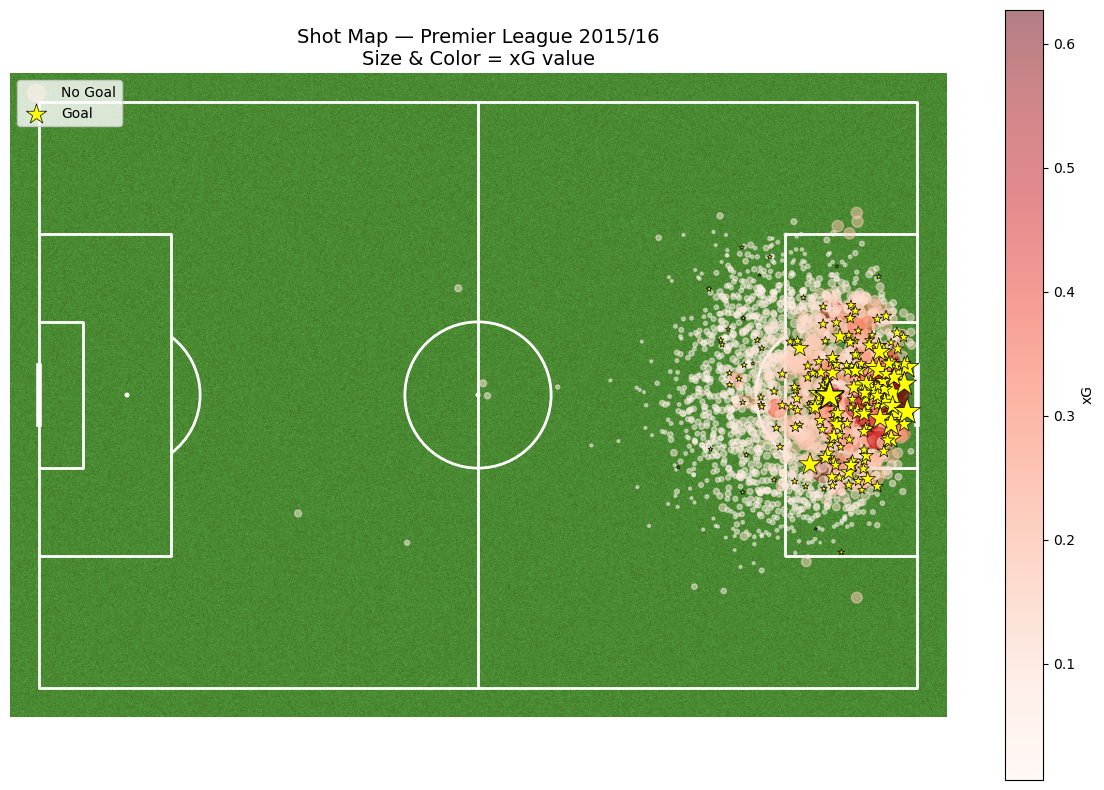

In [13]:
pitch = Pitch(pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))

# Plot shots colored by xG
shots_test = shots.loc[X_test.index].copy()
shots_test['our_xg'] = y_pred

goals = shots_test[shots_test['goal'] == 1]
no_goals = shots_test[shots_test['goal'] == 0]

# Non-goals
sc1 = pitch.scatter(no_goals['x'], no_goals['y'],
    s=no_goals['our_xg'] * 500,
    c=no_goals['our_xg'],
    cmap='Reds', alpha=0.5,
    ax=ax, label='No Goal')

# Goals
pitch.scatter(goals['x'], goals['y'],
    s=goals['our_xg'] * 500,
    marker='*', color='yellow',
    edgecolors='black', linewidths=0.5,
    ax=ax, label='Goal', zorder=3)

plt.colorbar(sc1, ax=ax, label='xG')
ax.legend(loc='upper left')
ax.set_title('Shot Map — Premier League 2015/16\nSize & Color = xG value', fontsize=14)
plt.show()

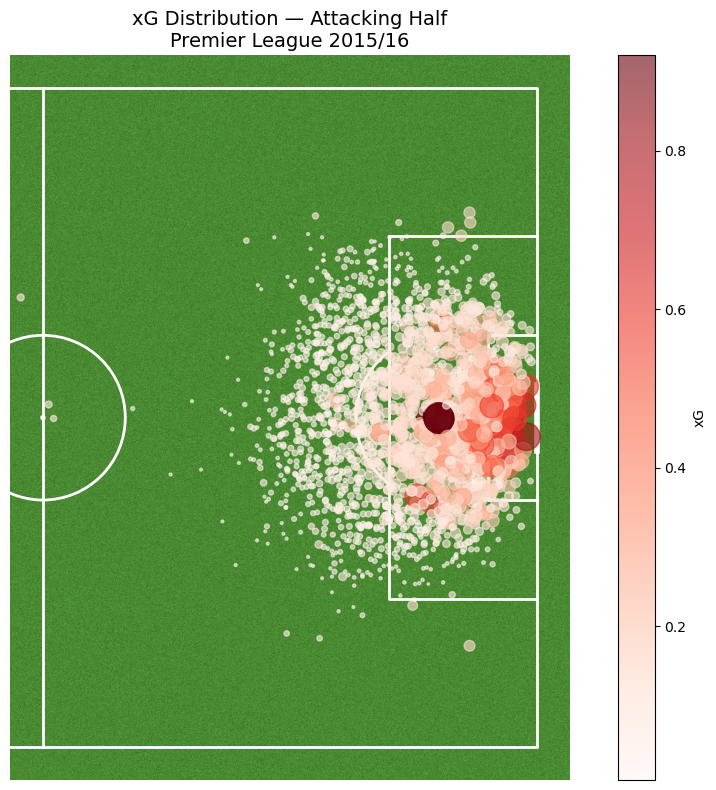

In [14]:
pitch = Pitch(pitch_color='grass', line_color='white', half=True)
fig, ax = pitch.draw(figsize=(10, 8))

sc = pitch.scatter(
    shots_test['x'], shots_test['y'],
    s=shots_test['our_xg'] * 500,
    c=shots_test['our_xg'],
    cmap='Reds', alpha=0.6,
    ax=ax
)

plt.colorbar(sc, ax=ax, label='xG')
ax.set_title('xG Distribution — Attacking Half\nPremier League 2015/16', fontsize=14)
plt.show()

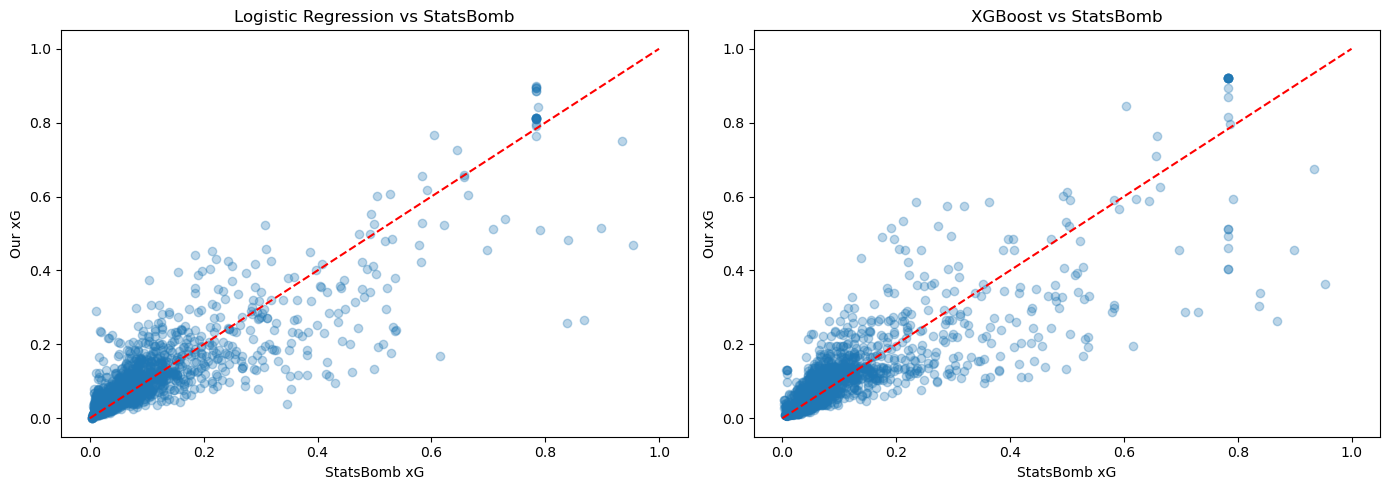

LogReg correlation: 0.876
XGBoost correlation: 0.841


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LogReg xG
axes[0].scatter(
    shots.loc[X_test.index, 'shot_statsbomb_xg'],
    log_grid.predict_proba(X_test)[:, 1],
    alpha=0.3
)
axes[0].plot([0, 1], [0, 1], 'r--')
axes[0].set_title('Logistic Regression vs StatsBomb')
axes[0].set_xlabel('StatsBomb xG')
axes[0].set_ylabel('Our xG')

# XGBoost xG
axes[1].scatter(
    shots.loc[X_test.index, 'shot_statsbomb_xg'],
    y_pred,
    alpha=0.3
)
axes[1].plot([0, 1], [0, 1], 'r--')
axes[1].set_title('XGBoost vs StatsBomb')
axes[1].set_xlabel('StatsBomb xG')
axes[1].set_ylabel('Our xG')

plt.tight_layout()
plt.show()

print(f'LogReg correlation: {pd.Series(log_grid.predict_proba(X_test)[:,1], index=X_test.index).corr(shots.loc[X_test.index, "shot_statsbomb_xg"]):.3f}')
print(f'XGBoost correlation: {pd.Series(y_pred, index=X_test.index).corr(shots.loc[X_test.index, "shot_statsbomb_xg"]):.3f}')

In [16]:
shots['my_xg'] = xgb_grid.predict_proba(X)[:, 1]

team_xg = shots.groupby('team').agg(
    xG_for=('my_xg', 'sum'),
    actual_goals=('goal', 'sum'),
    shots=('goal', 'count')
).round(2)

team_xg['xG_diff'] = team_xg['actual_goals'] - team_xg['xG_for']
team_xg['goal_prob.'] = (team_xg['actual_goals'] / team_xg['shots']) * 100
team_xg = team_xg.sort_values('xG_diff', ascending=False)
print(team_xg.head())

                      xG_for  actual_goals  shots   xG_diff  goal_prob.
team                                                                   
Manchester City    62.889999            71    614  8.110001   11.563518
West Ham United    56.279999            64    559  7.720001   11.449016
Tottenham Hotspur  61.340000            68    656  6.660000   10.365854
Liverpool          57.220001            62    635  4.779999    9.763780
Everton            51.880001            56    498  4.119999   11.244980


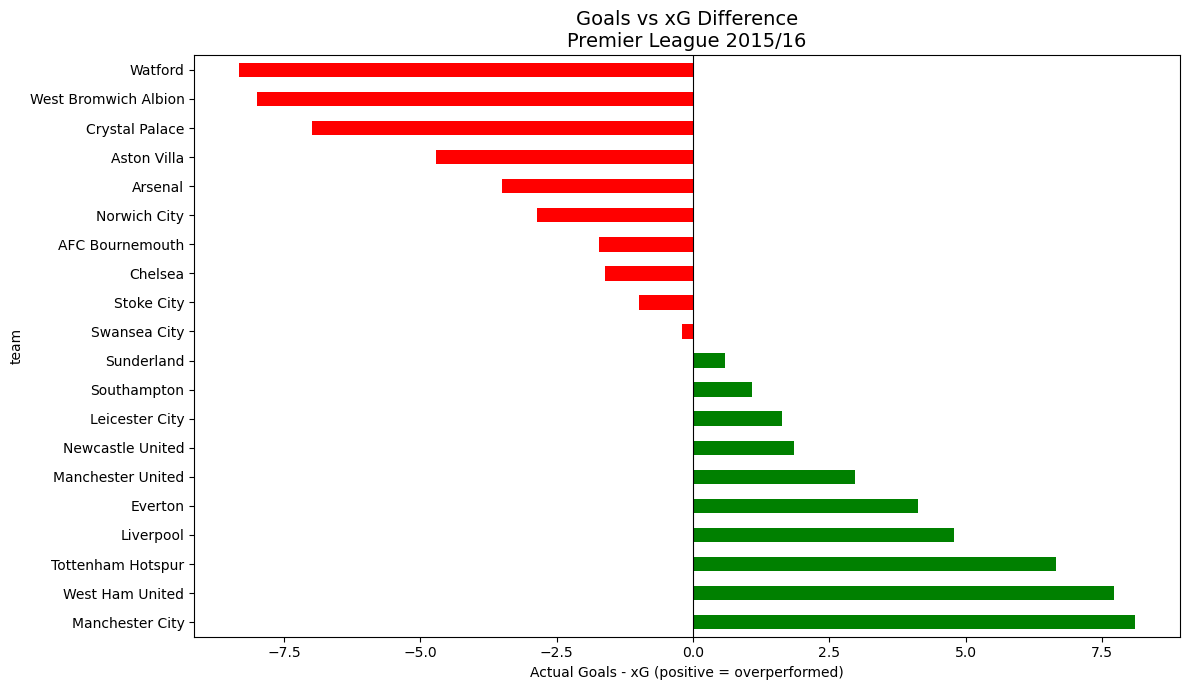

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['green' if x > 0 else 'red' for x in team_xg['xG_diff']]
team_xg['xG_diff'].plot(kind='barh', color=colors, ax=ax)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Goals vs xG Difference\nPremier League 2015/16', fontsize=14)
ax.set_xlabel('Actual Goals - xG (positive = overperformed)')
plt.tight_layout()
plt.show()